In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.templates.default = 'plotly_white'

In [45]:
df = pd.read_csv("C:/Users/karti/Downloads/customer_acquisition_data.csv")
df

,customer_id,channel,cost,conversion_rate,revenue
0,1,referral,8.320327,0.123145,4199
1,2,paid advertising,30.450327,0.016341,3410
2,3,email marketing,5.246263,0.043822,3164
3,4,social media,9.546326,0.167592,1520
4,5,referral,8.320327,0.123145,2419
...,...,...,...,...,...
795,796,social media,9.546326,0.167592,2813
796,797,email marketing,5.246263,0.043822,3439
797,798,social media,9.546326,0.167592,2101
798,799,paid advertising,30.450327,0.016341,813


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      800 non-null    int64  
 1   channel          800 non-null    object 
 2   cost             800 non-null    float64
 3   conversion_rate  800 non-null    float64
 4   revenue          800 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 31.4+ KB


In [47]:
df.isnull().sum()

customer_id        0
channel            0
cost               0
conversion_rate    0
revenue            0
dtype: int64

In [48]:
df.describe()

,customer_id,cost,conversion_rate,revenue
count,800.0000,800.000000,800.000000,800.000000
mean,400.5000,13.148052,0.086305,2769.151250
std,231.0844,9.922337,0.059611,1259.543706
min,1.0000,5.246263,0.016341,500.000000
25%,200.7500,5.246263,0.043822,1694.000000
50%,400.5000,8.320327,0.043822,2764.000000
75%,600.2500,9.546326,0.123145,3824.250000
max,800.0000,30.450327,0.167592,4998.000000


In [49]:
df['channel'].unique()

array(['referral', 'paid advertising', 'email marketing', 'social media'],
      dtype=object)

# Make a visualization for the distribution of Customer Acquasition Cost

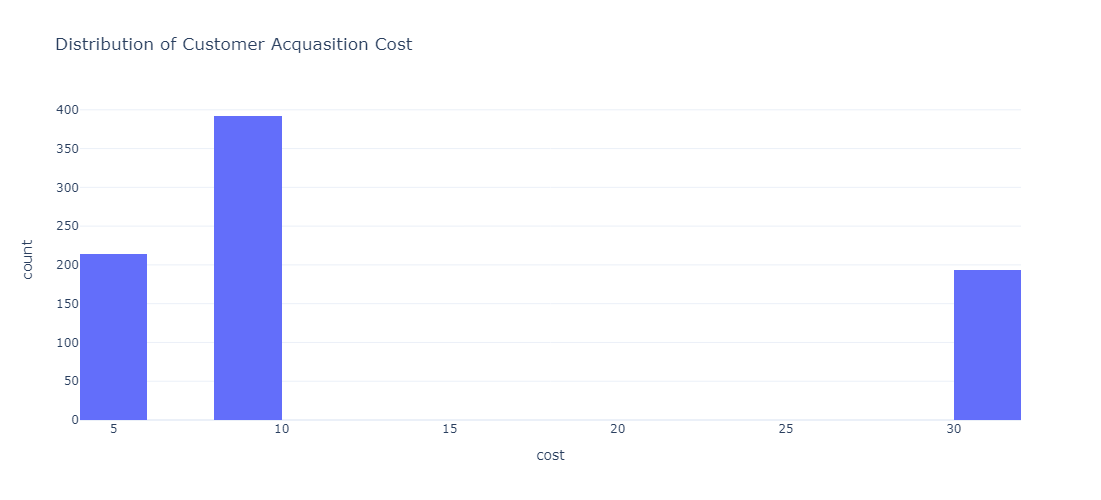

In [50]:
fig = px.histogram(data_frame=df, x='cost', title='Distribution of Customer Acquasition Cost', height=500, nbins=20)
fig.show()

# Create a Visualization for the revenue generated by the customer

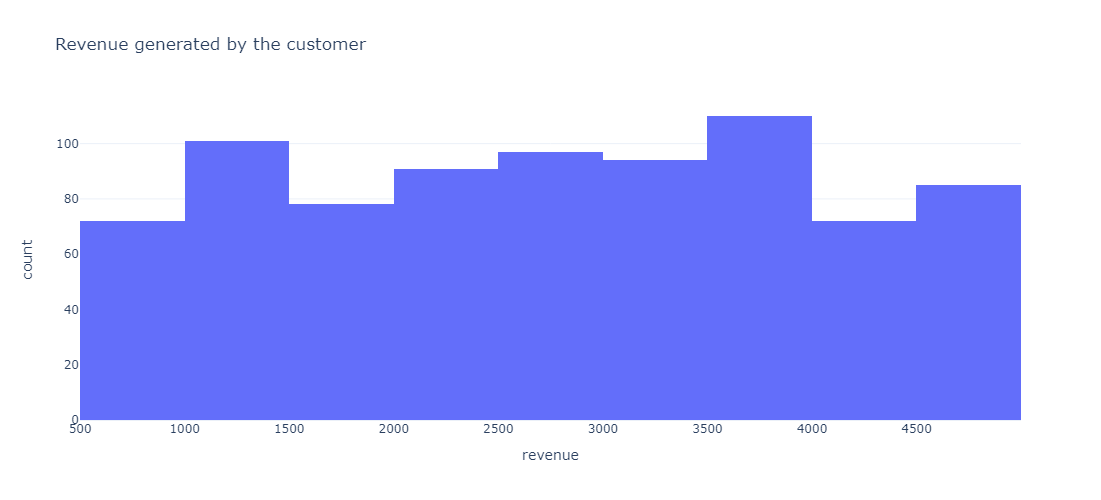

In [51]:
fig = px.histogram(data_frame=df, x='revenue', title='Revenue generated by the customer', height=500, nbins=20)
fig.show()

# Compare the cost of aquasition across various channels and determine which ones are the most least profitable

In [52]:
least_channel = df.groupby('channel')['cost'].mean().reset_index()
least_channel

,channel,cost
0,email marketing,5.246263
1,paid advertising,30.450327
2,referral,8.320327
3,social media,9.546326


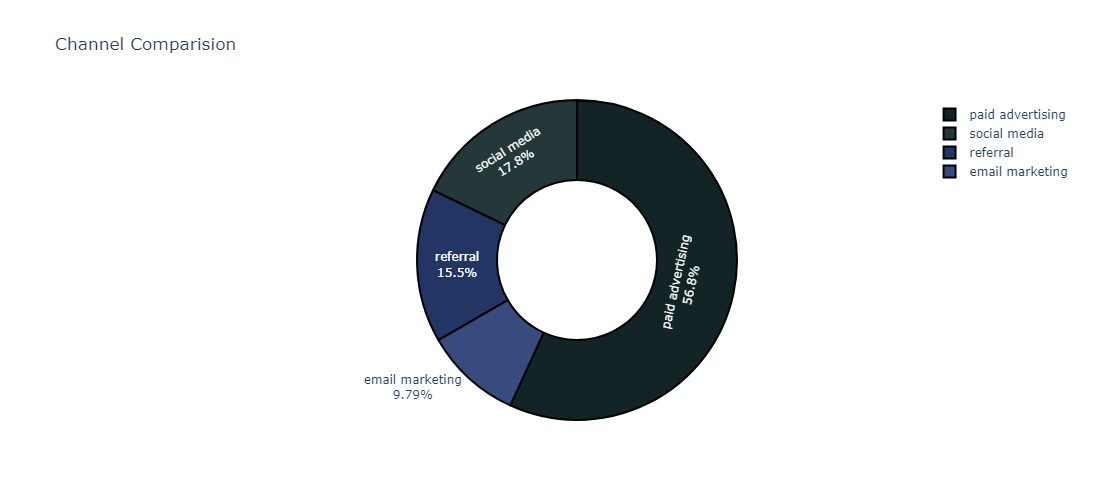

In [53]:
fig = px.pie(data_frame=least_channel, names='channel', values='cost', title='Channel Comparision', height=500, hole=0.5)
fig.update_traces(hoverinfo='percent+label', textinfo='percent+label', marker=dict(colors=['rgb(56, 75, 126)', 'rgb(18, 36, 37)', 'rgb(34, 53, 101)', 'rgb(36, 55, 57)', 'rgb(6, 4, 4)'], line=dict(color='black', width=2)))
fig.show()

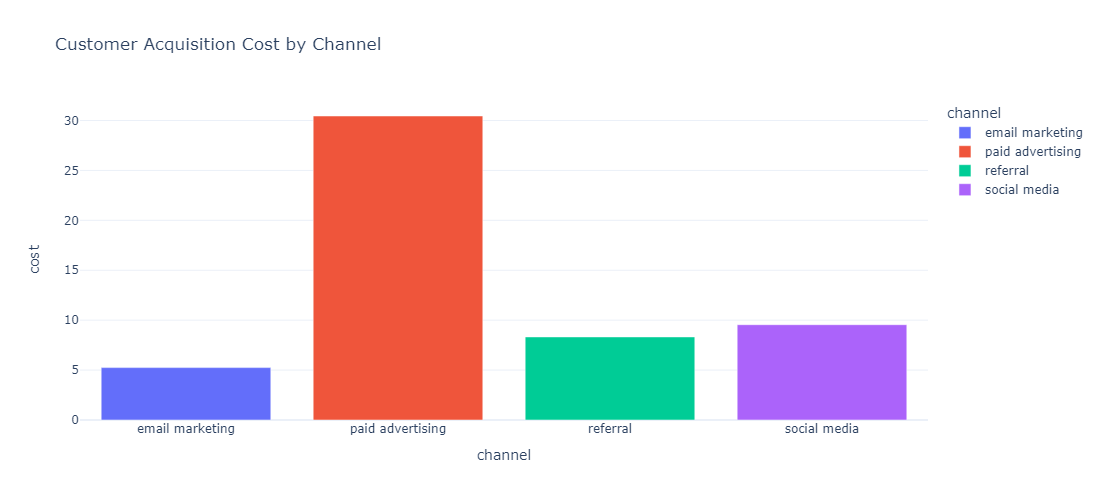

In [54]:
fig = px.bar(data_frame=least_channel, x='channel', y='cost', title='Customer Acquisition Cost by Channel', height=500, color='channel')
fig.show()

# Find out which channels are most and least effective at converting customer

In [55]:
convert_least_channel = df.groupby('channel')['conversion_rate'].mean().reset_index()
convert_least_channel

,channel,conversion_rate
0,email marketing,0.043822
1,paid advertising,0.016341
2,referral,0.123145
3,social media,0.167592


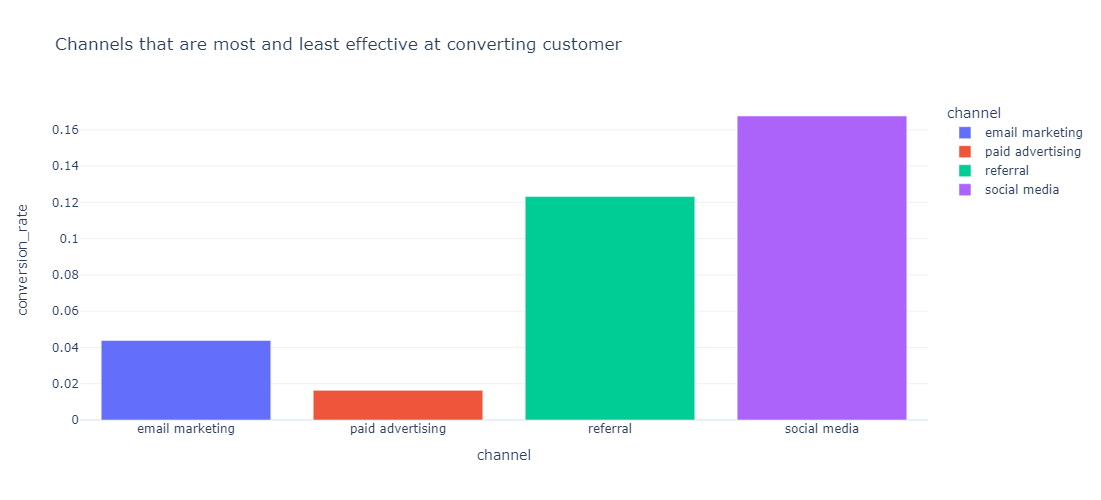

In [56]:
fig = px.bar(data_frame=convert_least_channel, x='channel', y='conversion_rate', title='Channels that are most and least effective at converting customer', height=500, color='channel')
fig.show()

# Calculate the total revenue by channel and analyze the most and least profitable channnels in terms of generating revenue 

In [57]:
revenue_by_channel = df.groupby('channel')[['cost', 'revenue']].sum().reset_index()
revenue_by_channel

,channel,cost,revenue
0,email marketing,1122.700340,604706
1,paid advertising,5907.363479,548396
2,referral,1722.307634,569552
3,social media,1766.070249,492667


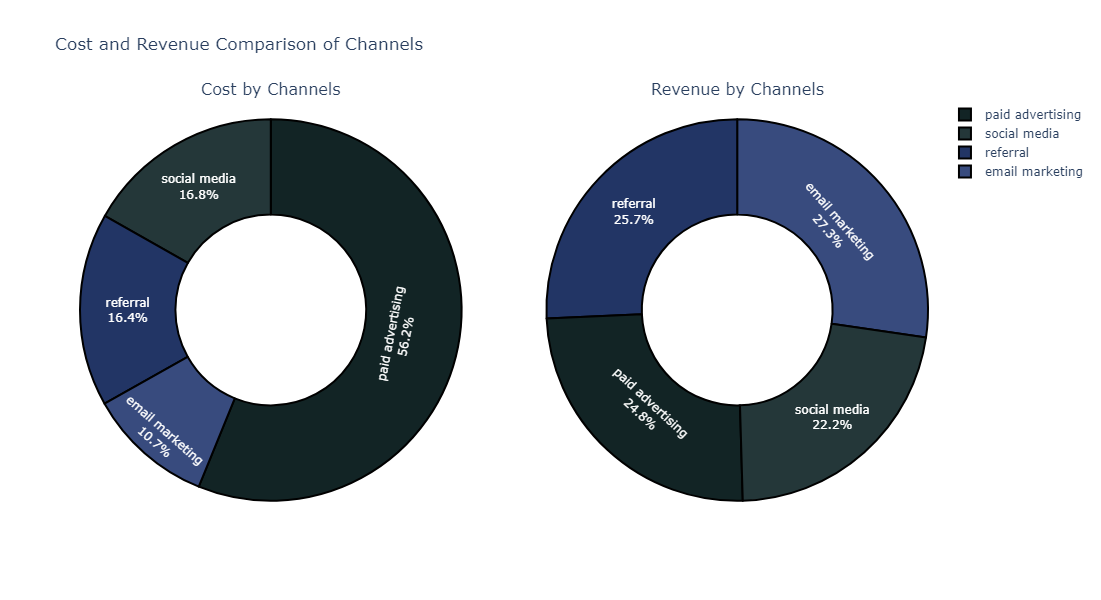

In [83]:
fig = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}]], subplot_titles=['Cost by Channels', 'Revenue by Channels'])
fig.add_trace(go.Pie(labels=revenue_by_channel['channel'], values=revenue_by_channel['cost'], name='Cost by Channels'), 1, 1)
fig.add_trace(go.Pie(labels=revenue_by_channel['channel'], values=revenue_by_channel['revenue'], name='Revenue by Channels'), 1, 2)
fig.update_traces(hoverinfo='percent+label', textinfo='percent+label', hole=0.5, marker=dict(colors=['rgb(56, 75, 126)', 'rgb(18, 36, 37)', 'rgb(34, 53, 101)', 'rgb(36, 55, 57)', 'rgb(6, 4, 4)'], line=dict(color='black', width=2)))
fig.update_layout(title = 'Cost and Revenue Comparison of Channels', autosize=False, height=600, width=900)
fig.show()

# Calculate the return on investment (ROI) for each channel

In [84]:
df.head()

,customer_id,channel,cost,conversion_rate,revenue
0,1,referral,8.320327,0.123145,4199
1,2,paid advertising,30.450327,0.016341,3410
2,3,email marketing,5.246263,0.043822,3164
3,4,social media,9.546326,0.167592,1520
4,5,referral,8.320327,0.123145,2419


In [85]:
df['ROI'] = df['revenue']/df['cost']
df.head()

,customer_id,channel,cost,conversion_rate,revenue,ROI
0,1,referral,8.320327,0.123145,4199,504.667681
1,2,paid advertising,30.450327,0.016341,3410,111.985660
2,3,email marketing,5.246263,0.043822,3164,603.095925
3,4,social media,9.546326,0.167592,1520,159.223564
4,5,referral,8.320327,0.123145,2419,290.733775


In [86]:
channel_ROI = df.groupby('channel')['ROI'].mean().reset_index()
channel_ROI

,channel,ROI
0,email marketing,538.617455
1,paid advertising,92.832615
2,referral,330.691213
3,social media,278.962290


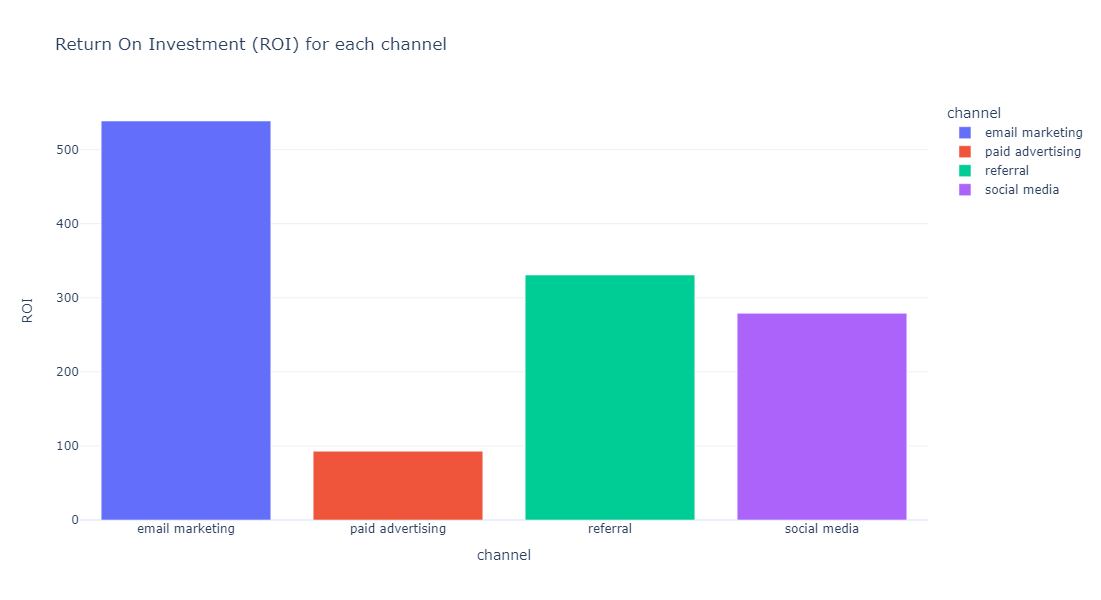

In [88]:
fig = px.bar(data_frame=channel_ROI, x='channel', y='ROI', title='Return On Investment (ROI) for each channel', height=600, color='channel')
fig.show()